# Precios de la vivienda en la CDMX

Este notebook analiza precios de vivienda de la CDMX con el objetivo de predecir valores de una vivienda hipotética según su tipo, superficie y ubicación dentro de la Ciudad de México.

### Pregunta de análisis

¿Es posible predecir mediante una regresión lineal el precio de un inmueble a partir de su ubicación, superficie y tipo?

A partir de los datos del dataset "Housing Prices in CDMX" se aplicará un algoritmo de regresión, con el objetivo de ver qué tanto se puede predecir el precio de inmuebles hipotéticos a partir de los datos existentes. El dataset contiene variables como la delegación en la que se ubica el inmueble, sus coordenadas, superficie total, superficie construida, precio total y por metro cuadrado. Para este ejercicio se utilizará la ubicación en latitud y longitud, el tipo de inmueble y la superficie, la variable objetivo es el precio.

Estas predicciones pueden ser de utilidad para potenciales constructores y compradores de vivienda en la ciudad, de forma que puedan conocer el mercado de forma anticipada y eso les permita tomar mejores decisiones.

## 1. Carga y análisis del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Configuración visual para que las gráficas se vean de forma consistente
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

# Crear la carpeta de visualizaciones si no existe
visualizations_dir = Path('visualizations')
visualizations_dir.mkdir(exist_ok=True)

print('Bibliotecas importadas correctamente')

Bibliotecas importadas correctamente


In [2]:
# Cargar el archivo CSV desde la carpeta del proyecto
csv_path = Path('housing_data_CDMX_v2.csv')
df = pd.read_csv(csv_path)

# Mostrar información básica del dataset cargado
print(f'Archivo cargado: {csv_path}')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
df.head()

Archivo cargado: housing_data_CDMX_v2.csv
Filas: 18234
Columnas: 13


,property_type,places,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,lat,lon
0,apartment,MiguelHidalgo,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,54.0,54.0,5366.215926,101851.85190,23.634501,-102.552788
1,house,Iztapalapa,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,80.0,80.0,995.774500,18900.00000,19.310330,-99.068557
2,apartment,Tlalpan,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,100.0,100.0,488.228200,9266.67000,19.279771,-99.234597
3,apartment,MiguelHidalgo,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,135.0,135.0,2501.632296,47481.48148,23.634501,-102.552788
4,apartment,MiguelHidalgo,"19.432657,-99.177444",4416000.0,MXN,4376051.62,232663.51,87.0,87.0,2674.293218,50758.62069,19.432657,-99.177444


In [3]:
# Mostrar resumen estructural del dataframe: tipos de datos y columnas
print(df.info())
print('\nColumnas:', list(df.columns))
print('\nPrimeras 5 filas:\n', df.head().to_string(index=False))

<class 'pandas.DataFrame'>
RangeIndex: 18234 entries, 0 to 18233
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_type               18234 non-null  str    
 1   places                      18234 non-null  str    
 2   lat-lon                     18234 non-null  str    
 3   price                       18234 non-null  float64
 4   currency                    18234 non-null  str    
 5   price_aprox_local_currency  18234 non-null  float64
 6   price_aprox_usd             18234 non-null  float64
 7   surface_total_in_m2         18234 non-null  float64
 8   surface_covered_in_m2       18234 non-null  float64
 9   price_usd_per_m2            18234 non-null  float64
 10  price_per_m2                18234 non-null  float64
 11  lat                         18234 non-null  float64
 12  lon                         18234 non-null  float64
dtypes: float64(9), str(4)
memory usage: 1.8 MB

A continuación se eliminan algunas columnas que no se utilizarán para la regresión, por considerar que contienen información redundante o que aportan ruido innecesario.

In [4]:
# Preparación de columnas para el análisis y el modelado
# Se eliminan columnas que no aportan información útil para predecir el precio

columns_to_drop = [
    'currency',
    'price_aprox_usd',
    'price_usd_per_m2',
    'lat-lon',
    'price_aprox_local_currency',
    'places'
]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print('Columnas restantes:')
print(list(df.columns))
df.head()


Columnas restantes:
['property_type', 'price', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_per_m2', 'lat', 'lon']


,property_type,price,surface_total_in_m2,surface_covered_in_m2,price_per_m2,lat,lon
0,apartment,5500000.0,54.0,54.0,101851.85190,23.634501,-102.552788
1,house,1512000.0,80.0,80.0,18900.00000,19.310330,-99.068557
2,apartment,926667.0,100.0,100.0,9266.67000,19.279771,-99.234597
3,apartment,6410000.0,135.0,135.0,47481.48148,23.634501,-102.552788
4,apartment,4416000.0,87.0,87.0,50758.62069,19.432657,-99.177444


Ahora se eliminan algunos outliers utilizando el método del rango intercuartílico, considerando aquellas columnas que podrían ser propensas a contener outliers (precio, superficie total y superficie construida)

In [5]:
# Limpieza de outliers para las variables numéricas más relevantes

numeric_cols_for_outliers = ['price', 'surface_total_in_m2', 'surface_covered_in_m2']

for col in numeric_cols_for_outliers:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        count_before = len(df)
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()
        count_after = len(df)
        print(f'{col}: {count_before - count_after} valores atípicos eliminados')

print('\nDataset después de limpiar outliers:')
print(df.shape)
df.head()

price: 1538 valores atípicos eliminados
surface_total_in_m2: 1543 valores atípicos eliminados
surface_covered_in_m2: 1218 valores atípicos eliminados

Dataset después de limpiar outliers:
(13935, 7)


,property_type,price,surface_total_in_m2,surface_covered_in_m2,price_per_m2,lat,lon
0,apartment,5500000.0,54.0,54.0,101851.85190,23.634501,-102.552788
1,house,1512000.0,80.0,80.0,18900.00000,19.310330,-99.068557
2,apartment,926667.0,100.0,100.0,9266.67000,19.279771,-99.234597
3,apartment,6410000.0,135.0,135.0,47481.48148,23.634501,-102.552788
4,apartment,4416000.0,87.0,87.0,50758.62069,19.432657,-99.177444


In [6]:
# Detectar valores faltantes y duplicados para decidir si limpiar el dataset
missing_values = df.isnull().sum()
duplicates = df.duplicated().sum()

print('Valores faltantes:\n', missing_values[missing_values > 0])
print(f'\nDuplicados: {duplicates}')

# Eliminar duplicados si existen para evitar sesgos en el entrenamiento
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Duplicados eliminados')

Valores faltantes:
 Series([], dtype: int64)

Duplicados: 2972
Duplicados eliminados


Dado que se utilizará la columna de tipo de propiedad y esta es información categórica, se hará un one-hot encoding de esta información.

In [7]:
# One-hot encoding de la columna property_type
# Esto convierte la categoría en columnas binarias para que los modelos puedan usarla
if 'property_type' in df.columns:
    property_type_dummies = pd.get_dummies(df['property_type'], prefix='property_type', dtype=int)
    df = pd.concat([df, property_type_dummies], axis=1)
    property_type_dummy_cols = list(property_type_dummies.columns)
    print('Columnas dummy creadas para property_type:')
    print(property_type_dummy_cols)
else:
    property_type_dummy_cols = [col for col in df.columns if col.startswith('property_type_')]
    print('La columna property_type no existe en el dataframe.')

if property_type_dummy_cols:
    df[property_type_dummy_cols].head()
else:
    print('No se encontraron columnas dummy de property_type.')

Columnas dummy creadas para property_type:
['property_type_PH', 'property_type_apartment', 'property_type_house', 'property_type_store']


In [8]:
# Resumen estadístico del dataset para identificar tendencias y rangos de valores
# Esto ayuda a entender la distribución de las variables antes de entrenar modelos

print(df.head(5))
df.describe(include='all').T

  property_type      price  surface_total_in_m2  surface_covered_in_m2  \
0     apartment  5500000.0                 54.0                   54.0   
1         house  1512000.0                 80.0                   80.0   
2     apartment   926667.0                100.0                  100.0   
3     apartment  6410000.0                135.0                  135.0   
4     apartment  4416000.0                 87.0                   87.0   

   price_per_m2        lat         lon  property_type_PH  \
0  101851.85190  23.634501 -102.552788                 0   
1   18900.00000  19.310330  -99.068557                 0   
2    9266.67000  19.279771  -99.234597                 0   
3   47481.48148  23.634501 -102.552788                 0   
4   50758.62069  19.432657  -99.177444                 0   

   property_type_apartment  property_type_house  property_type_store  
0                        1                    0                    0  
1                        0                    1     

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
property_type,10963,4,apartment,8846,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,10963.0,NaN,NaN,NaN,2156323.490286,1673036.831216,148500.0,894500.0,1570000.0,2950000.0,8405651.0
surface_total_in_m2,10963.0,NaN,NaN,NaN,94.67892,45.058424,1.0,64.0,80.0,113.0,300.0
surface_covered_in_m2,10963.0,NaN,NaN,NaN,94.71121,44.105167,1.0,64.0,80.0,115.0,224.0
price_per_m2,10963.0,NaN,NaN,NaN,23724.729515,22800.584201,1500.0,12018.1298,18300.66667,31430.364071,930000.0
lat,10963.0,NaN,NaN,NaN,19.446514,0.529694,19.185852,19.357477,19.389338,19.431629,41.577487
lon,10963.0,NaN,NaN,NaN,-99.198449,0.410404,-102.552788,-99.186945,-99.157853,-99.129227,-90.488467
property_type_PH,10963.0,NaN,NaN,NaN,0.000456,0.021352,0.0,0.0,0.0,0.0,1.0
property_type_apartment,10963.0,NaN,NaN,NaN,0.806896,0.394752,0.0,1.0,1.0,1.0,1.0
property_type_house,10963.0,NaN,NaN,NaN,0.185624,0.388821,0.0,0.0,0.0,0.0,1.0


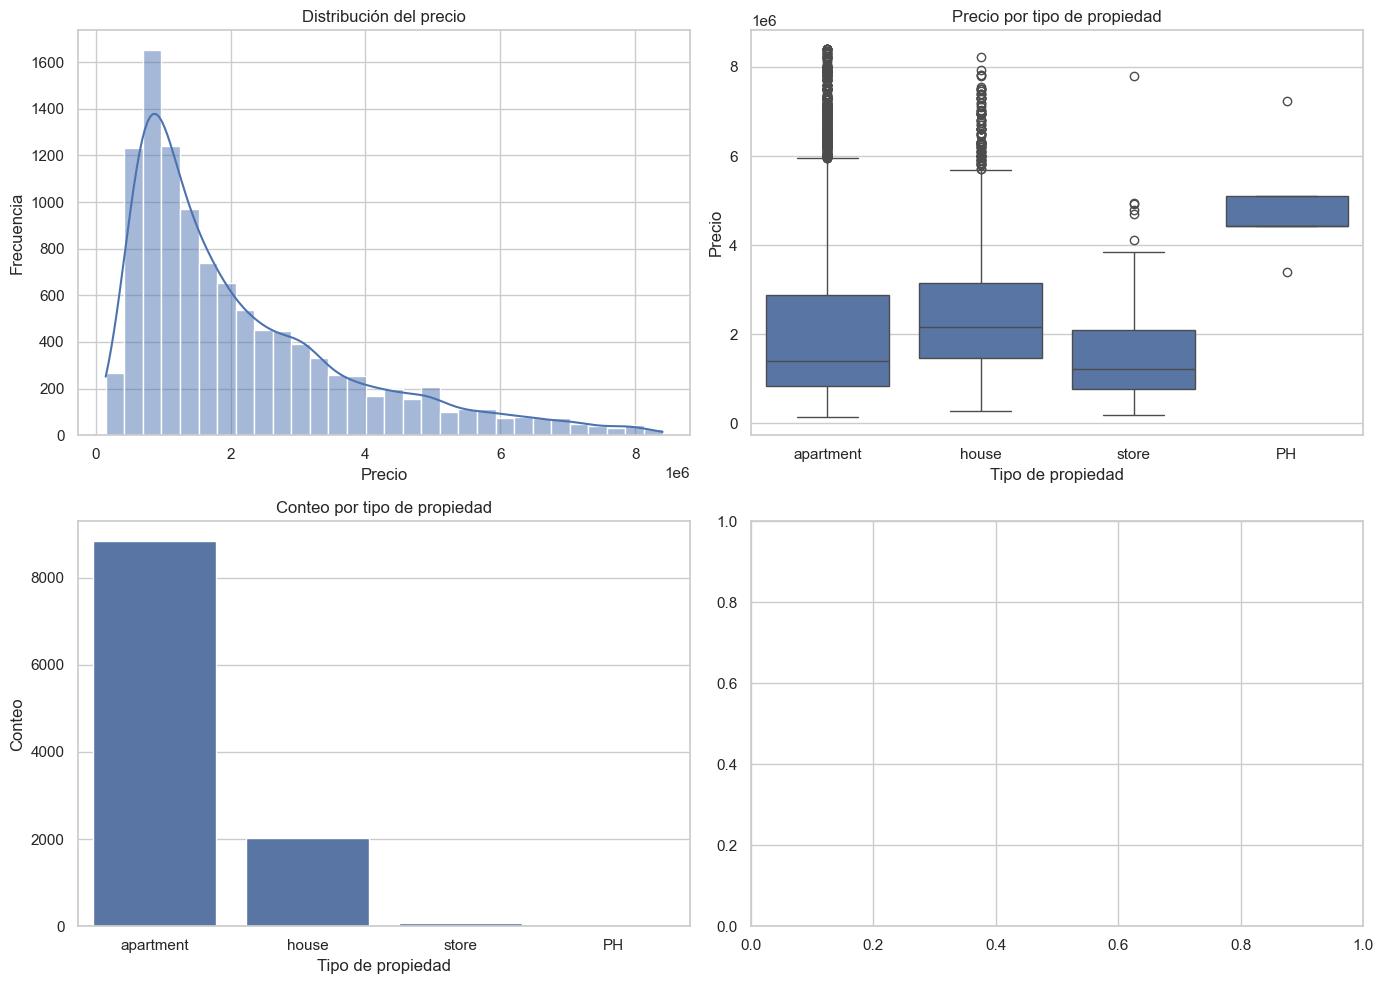

In [9]:
# Visualizaciones básicas para explorar la distribución del precio y la composición del dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma del precio para ver su distribución
plot_df = df[['price']].dropna()
sns.histplot(data=plot_df, x='price', bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribución del precio')
axes[0, 0].set_xlabel('Precio')
axes[0, 0].set_ylabel('Frecuencia')

# Caja y bigotes para comparar el precio por tipo de propiedad
sns.boxplot(data=df, x='property_type', y='price', ax=axes[0, 1])
axes[0, 1].set_title('Precio por tipo de propiedad')
axes[0, 1].set_xlabel('Tipo de propiedad')
axes[0, 1].set_ylabel('Precio')

# Conteo por tipo de propiedad para ver la frecuencia de cada categoría
sns.countplot(data=df, x='property_type', ax=axes[1, 0])
axes[1, 0].set_title('Conteo por tipo de propiedad')
axes[1, 0].set_xlabel('Tipo de propiedad')
axes[1, 0].set_ylabel('Conteo')

plt.tight_layout()
plt.savefig(visualizations_dir / '01_exploratory_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

A partir de estos datos ya normalizados, podemos analizar las relaciones entre las variables.

En la primera gráfica vemos que la mayoría de propiedades se ubican en costos entre 1 y 2 millones de pesos, aunque la media parece ser los 2.5 MDP de acuerdo con la información estadística.

Según la segunda gráfica, los rangos de precios suelen ser similares para la mayoría de las propiedades, con excepción de los penthouses que suelen moverse en un rango mayor; por otro lado, tanto casas como departamentos tiene outliers muy fuera del rango.

En la tercera gráfica vemos que la mayoría de datos corresponden a departamentos, con una proporción de 1:4 sobre casas; los locales comerciales y penthouses apenas figuran en este dataset.

## 2. Aplicación de modelos de aprendizaje automático supervisado

### 2.1 Modelo de regresión lineal

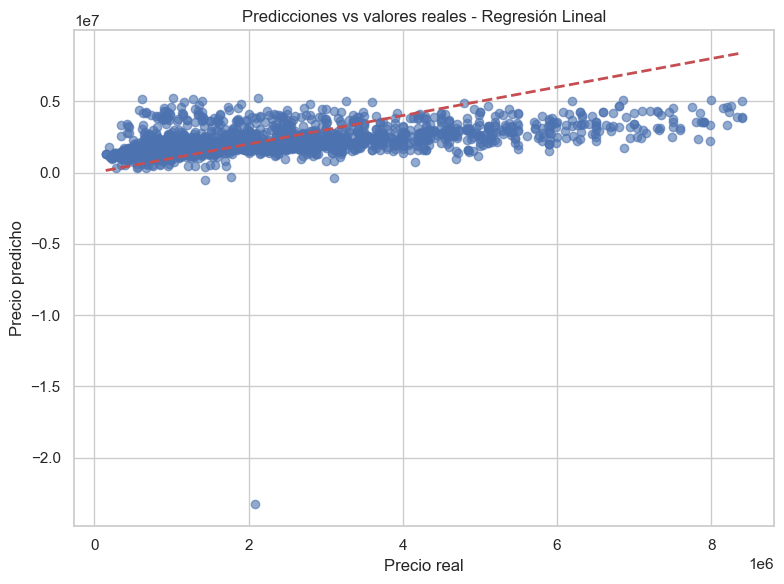

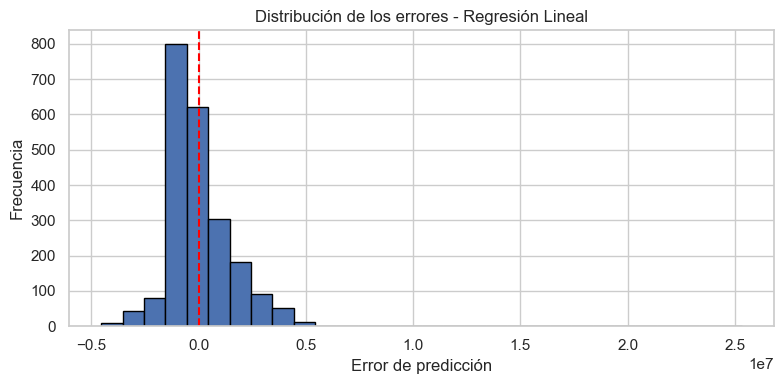

RMSE: 1509506.51
MAE: 1080809.34
MSE: 2278609897844.52
R2: 0.2023


,feature,coef
4,property_type_PH,1.188285e+06
3,lon,-1.072412e+06
5,property_type_house,-9.480046e+05
2,lat,-8.072388e+05
7,property_type_store,-1.254403e+05
6,property_type_apartment,-1.148397e+05
1,surface_covered_in_m2,1.789611e+04
0,surface_total_in_m2,3.818682e+03


In [10]:
# Seleccionar las columnas de entrada que se usarán para predecir el precio
# Se incluyen superficie, coordenadas y las columnas one-hot de property_type

df_model = df.copy()

feature_cols = [
    'surface_total_in_m2',
    'surface_covered_in_m2',
    'lat',
    'lon',
    'property_type_PH',
    'property_type_house',
    'property_type_apartment',
    'property_type_store'
]

target_col = 'price'
model_df = df_model[feature_cols + [target_col]].dropna()
X = model_df[feature_cols].astype(float)
y = model_df[target_col].astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar una regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Gráfica de dispersión para ver qué tan cerca están las predicciones de los valores reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predicciones vs valores reales - Regresión Lineal')
plt.tight_layout()
plt.savefig(visualizations_dir / '02_linear_regression_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Histograma de los errores para inspeccionar sesgos o valores atípicos
errors = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.hist(errors, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Error de predicción')
plt.ylabel('Frecuencia')
plt.title('Distribución de los errores - Regresión Lineal')
plt.tight_layout()
plt.savefig(visualizations_dir / '03_linear_regression_errors.png', dpi=300, bbox_inches='tight')
plt.show()

print('RMSE:', round(rmse, 2))
print('MAE:', round(mae, 2))
print('MSE:', round(mse, 2))
print('R2:', round(r2, 4))

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef': model.coef_
}).sort_values(by='coef', key=lambda s: s.abs(), ascending=False)

coef_df.head(10)

### Modelo de bosque aleatorio

Random Forest
MAE: 639345.21
MSE: 1047012508565.83
RMSE: 1023236.29
R2: 0.6335


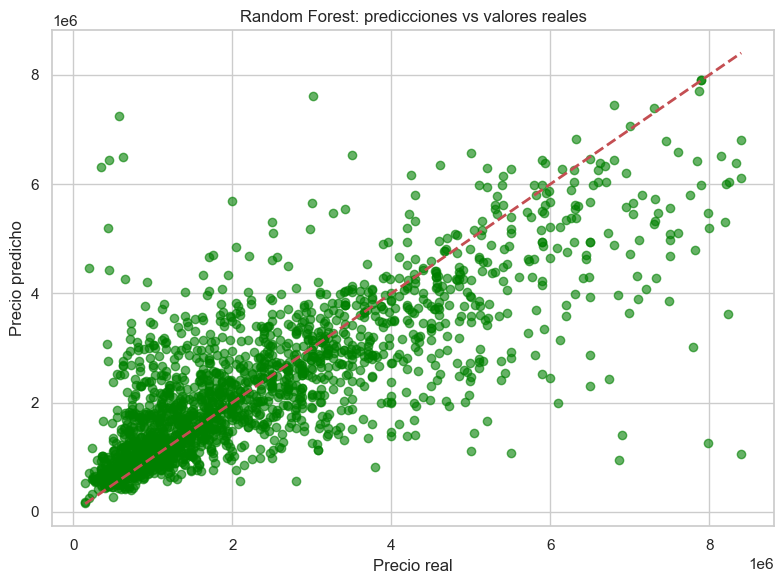

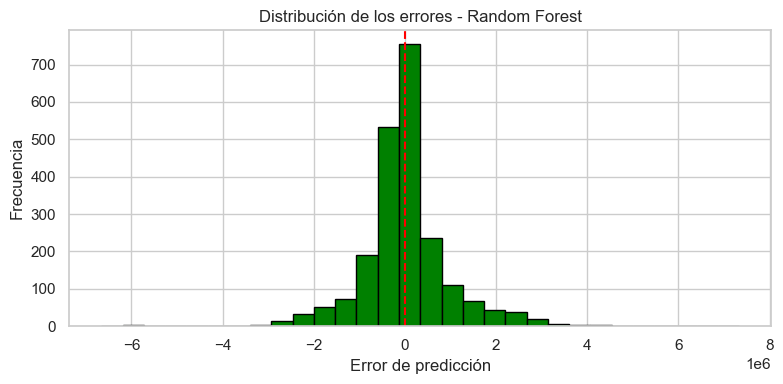


Comparación
Linear Regression R2: 0.2023
Random Forest R2: 0.6335


In [11]:
df_model = df.copy()

feature_cols = [
    'surface_total_in_m2',
#    'surface_covered_in_m2',
    'lat',
    'lon',
    'property_type_PH',
    'property_type_house',
    'property_type_apartment',
    'property_type_store'
]
target_col = 'price'
model_df = df_model[feature_cols + [target_col]].dropna()
X = model_df[feature_cols].astype(float)
y = model_df[target_col].astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar un Random Forest para comparar un modelo no lineal con regresión lineal
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluar el modelo con las mismas métricas que la regresión lineal
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print('Random Forest')
print('MAE:', round(rf_mae, 2))
print('MSE:', round(rf_mse, 2))
print('RMSE:', round(rf_rmse, 2))
print('R2:', round(rf_r2, 4))

# Visualización del rendimiento del Random Forest
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Random Forest: predicciones vs valores reales')
plt.tight_layout()
plt.savefig(visualizations_dir / '04_random_forest_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Histograma de los errores del modelo para inspeccionar sesgos o valores atípicos
rf_errors = y_test - rf_pred
plt.figure(figsize=(8, 4))
plt.hist(rf_errors, bins=30, edgecolor='black', color='green')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Error de predicción')
plt.ylabel('Frecuencia')
plt.title('Distribución de los errores - Random Forest')
plt.tight_layout()
plt.savefig(visualizations_dir / '05_random_forest_errors.png', dpi=300, bbox_inches='tight')
plt.show()

if 'r2' in globals():
    print('\nComparación')
    print('Linear Regression R2:', round(r2, 4))
    print('Random Forest R2:', round(rf_r2, 4))
else:
    print('\nLa regresión lineal no se ha ejecutado todavía, pero el Random Forest sí.')

### Modelo de regresión polinomial

Regresión polinomial
MAE: 1034551.9
MSE: 3040496696017.54
RMSE: 1743702.01
R2: -0.0644


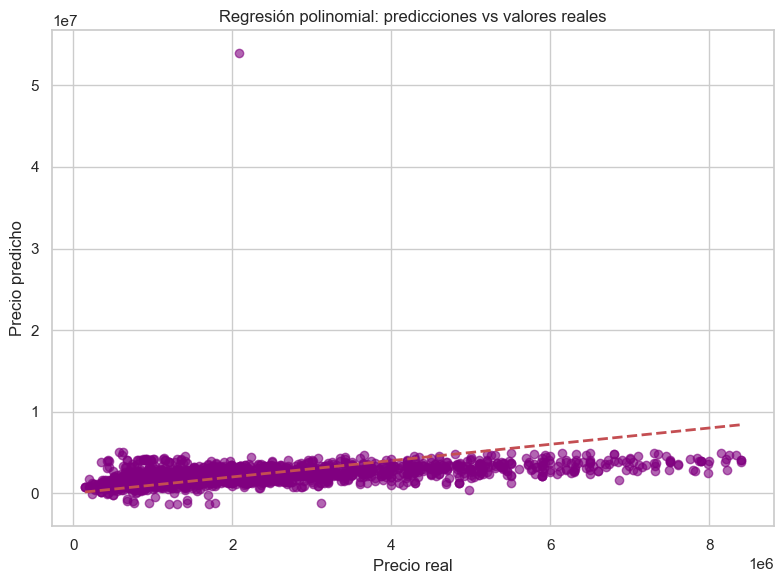

In [12]:
df_model = df.copy()

feature_cols = [
        'surface_total_in_m2',
        'surface_covered_in_m2',
        'lat',
        'lon',
        'property_type_PH',
        'property_type_house',
        'property_type_apartment',
        'property_type_store'
]
target_col = 'price'
model_df = df_model[feature_cols + [target_col]].dropna()
X = model_df[feature_cols].astype(float)
y = model_df[target_col].astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar una regresión polinomial de grado 2 para capturar relaciones no lineales
poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
poly_model.fit(X_train, y_train)

# Evaluar la regresión polinomial con las mismas métricas que los otros modelos
poly_pred = poly_model.predict(X_test)
poly_mae = mean_absolute_error(y_test, poly_pred)
poly_mse = mean_squared_error(y_test, poly_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test, poly_pred)

print('Regresión polinomial')
print('MAE:', round(poly_mae, 2))
print('MSE:', round(poly_mse, 2))
print('RMSE:', round(poly_rmse, 2))
print('R2:', round(poly_r2, 4))

# Visualizar la relación entre valores reales y predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, poly_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Regresión polinomial: predicciones vs valores reales')
plt.tight_layout()
plt.savefig(visualizations_dir / '06_polynomial_regression_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Tabla comparativa de resultados entre los modelos evaluados
comparison_df = pd.DataFrame({
    'Modelo': ['Regresión lineal', 'Random Forest', 'Regresión polinomial'],
    'R2': [r2, rf_r2, poly_r2],
    'MAE': [mae, rf_mae, poly_mae],
    'MSE': [mse, rf_mse, poly_mse],
    'RMSE': [rmse, rf_rmse, poly_rmse],
})

comparison_df.sort_values(by='R2', ascending=False)


,Modelo,R2,MAE,MSE,RMSE
1,Random Forest,0.633478,6.393452e+05,1.047013e+12,1.023236e+06
0,Regresión lineal,0.202340,1.080809e+06,2.278610e+12,1.509507e+06
2,Regresión polinomial,-0.064369,1.034552e+06,3.040497e+12,1.743702e+06


# Conclusión

Se aplicaron tres modelos supervisados y se obtuvieron resultados bastante distintos en cada uno.

R²:
El valor de R² = 0.6416 indica que el modelo Random Forest logra explicar aproximadamente el 64.16% de la variabilidad del precio de las propiedades a partir de las variables utilizadas: superficie total, superficie cubierta, latitud, longitud y tipo de propiedad. Esto significa que el modelo tiene una capacidad predictiva considerablemente mejor que los modelos lineal y polinomial, aunque todavía existe una parte importante del precio que no se explica con las variables disponibles. Es probable que esta variabilidad restante dependa de factores no incluidos en el modelo, como colonia o barrio específico, antigüedad del inmueble, número de habitaciones, estado de conservación, amenidades o cercanía a servicios.

MAE:
El MAE = 639,587.8 representa el error absoluto promedio del modelo. En términos prácticos, significa que las predicciones del Random Forest se equivocan, en promedio, por aproximadamente 639,588 unidades monetarias respecto al precio real de las propiedades. Esta métrica es útil porque se interpreta directamente en la misma escala que la variable objetivo. Aunque el error sigue siendo considerable, fue el menor entre los modelos evaluados, por lo que Random Forest presentó el mejor desempeño en términos de precisión promedio.

MSE:
El MSE = 1.061817 × 10¹² mide el promedio de los errores elevados al cuadrado. A diferencia del MAE, esta métrica penaliza con mayor fuerza los errores grandes, por lo que es especialmente sensible a predicciones muy alejadas del valor real. El valor obtenido es alto porque los precios de las propiedades están expresados en unidades monetarias grandes y porque los errores se elevan al cuadrado. Sin embargo, al compararlo con los otros modelos, Random Forest obtuvo el MSE más bajo, lo que indica que también fue el modelo que mejor controló los errores grandes dentro de los modelos evaluados.

## Recomendaciones

Aunque estos datos permiten una buena aproximación al problema, sería más recomendable utilizar variables adicionales para apoyar la predicción. Por ejemplo: antigüedad del inmueble, cercanía a transporte público o a vías de acceso rápido, cercanía a servicios educativos y recreativos, índices recientes de criminalidad en la zona, entre otros. 